# Principal Component Analysis with Cancer Data

In [3]:
#Import all the necessary modules
#Import all the necessary modules
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

# Q1. Load the Data file into Python DataFrame and view top 10 rows

In [6]:
cancer_data = pd.read_csv('cancer.csv')
cancer_data.head(10)

,ID,ClumpThickness,Cell Size,Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Normal Nucleoli,Bland Chromatin,Mitoses,Class
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2
5,1017122,8,10,10,8,7,10,9,7,1,4
6,1018099,1,1,1,1,2,10,3,1,1,2
7,1018561,2,1,2,1,2,1,3,1,1,2
8,1033078,2,1,1,1,2,1,1,1,5,2
9,1033078,4,2,1,1,2,1,2,1,1,2


In [0]:
  # Id columns is to identify rows hence can be skipped in analysis
  # All columns have numerical values
  # Class would be the target variable. Should be removed when PCA is done

# Q2 Print the datatypes of each column and the shape of the dataset. Perform descriptive analysis 

In [40]:
print(cancer_data.shape)
print(cancer_data.dtypes)
cancer_data.head(n=15)

(699, 11)
ID                             int64
ClumpThickness                 int64
Cell Size                      int64
Cell Shape                     int64
Marginal Adhesion              int64
Single Epithelial Cell Size    int64
Bare Nuclei                    int64
Normal Nucleoli                int64
Bland Chromatin                int64
Mitoses                        int64
Class                          int64
dtype: object


,ID,ClumpThickness,Cell Size,Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Normal Nucleoli,Bland Chromatin,Mitoses,Class
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2
5,1017122,8,10,10,8,7,10,9,7,1,4
6,1018099,1,1,1,1,2,10,3,1,1,2
7,1018561,2,1,2,1,2,1,3,1,1,2
8,1033078,2,1,1,1,2,1,1,1,5,2
9,1033078,4,2,1,1,2,1,2,1,1,2


In [41]:
cancer_data.isnull().any()

ID                             False
ClumpThickness                 False
Cell Size                      False
Cell Shape                     False
Marginal Adhesion              False
Single Epithelial Cell Size    False
Bare Nuclei                    False
Normal Nucleoli                False
Bland Chromatin                False
Mitoses                        False
Class                          False
dtype: bool

In [42]:
cancer_data['Class'].value_counts()

2    458
4    241
Name: Class, dtype: int64

In [43]:
# Cleaning of data
# Remove unnecessary columns
cancer_data = cancer_data.replace('?', np.nan)
cancer_data.head(20)

,ID,ClumpThickness,Cell Size,Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Normal Nucleoli,Bland Chromatin,Mitoses,Class
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2
5,1017122,8,10,10,8,7,10,9,7,1,4
6,1018099,1,1,1,1,2,10,3,1,1,2
7,1018561,2,1,2,1,2,1,3,1,1,2
8,1033078,2,1,1,1,2,1,1,1,5,2
9,1033078,4,2,1,1,2,1,2,1,1,2


In [44]:
cancer_data['Class'].value_counts()
cancer_data.describe()

,ID,ClumpThickness,Cell Size,Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Normal Nucleoli,Bland Chromatin,Mitoses,Class
count,6.990000e+02,699.000000,699.000000,699.000000,699.000000,699.000000,699.000000,699.000000,699.000000,699.000000,699.000000
mean,1.071704e+06,4.417740,3.134478,3.207439,2.806867,3.216023,3.486409,3.437768,2.866953,1.589413,2.689557
std,6.170957e+05,2.815741,3.051459,2.971913,2.855379,2.214300,3.621929,2.438364,3.053634,1.715078,0.951273
min,6.163400e+04,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,2.000000
25%,8.706885e+05,2.000000,1.000000,1.000000,1.000000,2.000000,1.000000,2.000000,1.000000,1.000000,2.000000
50%,1.171710e+06,4.000000,1.000000,1.000000,1.000000,2.000000,1.000000,3.000000,1.000000,1.000000,2.000000
75%,1.238298e+06,6.000000,5.000000,5.000000,4.000000,4.000000,5.000000,5.000000,4.000000,1.000000,4.000000
max,1.345435e+07,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,10.000000,4.000000


In [53]:
## Find missing values
print('Missing values {0}'.format(cancer_data.isnull().sum()))

# Find duplicated records
print('Duplicate records {0}'.format(cancer_data.duplicated().sum()))

# Find the unique values of 'diagnosis'.
print('cancer_data Unique values of "Class": {}'.format(cancer_data['Class'].unique()))

Missing values ID                             0
ClumpThickness                 0
Cell Size                      0
Cell Shape                     0
Marginal Adhesion              0
Single Epithelial Cell Size    0
Bare Nuclei                    0
Normal Nucleoli                0
Bland Chromatin                0
Mitoses                        0
Class                          0
dtype: int64
Duplicate records 9
cancer_data Unique values of "Class": [2 4]


# Q3 Check for missing value check, incorrect data, duplicate data and perform imputation with mean, median, mode as necessary.


In [46]:
# We could see "?" values in column, this should be removed from data set

# Check for missing value in any other column

In [47]:
# No missing values found. So let us try to remove ? from bare nuclei column

# Get count of rows having ?
cancer_data = cancer_data.replace('?', np.nan)
cancer_data.head(20)

,ID,ClumpThickness,Cell Size,Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Normal Nucleoli,Bland Chromatin,Mitoses,Class
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2
5,1017122,8,10,10,8,7,10,9,7,1,4
6,1018099,1,1,1,1,2,10,3,1,1,2
7,1018561,2,1,2,1,2,1,3,1,1,2
8,1033078,2,1,1,1,2,1,1,1,5,2
9,1033078,4,2,1,1,2,1,2,1,1,2


In [48]:
# 16 values are corrupted. We can either delete them as it forms roughly 2% of data.
# Here we would like to impute it with suitable values

In [49]:
cancer_data.isna().sum()

ID                             0
ClumpThickness                 0
Cell Size                      0
Cell Shape                     0
Marginal Adhesion              0
Single Epithelial Cell Size    0
Bare Nuclei                    0
Normal Nucleoli                0
Bland Chromatin                0
Mitoses                        0
Class                          0
dtype: int64

In [50]:
cancer_data = cancer_data.apply(lambda x: x.fillna(x.median()),axis=0)
cancer_data.isna().sum()

ID                             0
ClumpThickness                 0
Cell Size                      0
Cell Shape                     0
Marginal Adhesion              0
Single Epithelial Cell Size    0
Bare Nuclei                    0
Normal Nucleoli                0
Bland Chromatin                0
Mitoses                        0
Class                          0
dtype: int64

In [51]:
cancer_data['Bare Nuclei'] = cancer_data['Bare Nuclei'].astype('int64')

In [52]:
print('Duplicate records {0}'.format(cancer_data.duplicated().sum()))

Duplicate records 9


In [56]:
cancer_data.drop_duplicates(keep='first',inplace=True)
cancer_data.shape

(690, 11)

# Q4. Perform bi variate analysis including correlation & pairplots. 


In [0]:
# Check for correlation of variable

In [0]:
# Cell size shows high significance with cell shape,marginal adhesion, single epithelial cell size,bare nuclei, normal nucleoli 
# and bland chromatin
# Target variable shows high correlation with most of these variables

/anaconda3/lib/python3.7/site-packages/scipy/stats/stats.py:1713: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  return np.add.reduce(sorted[indexer] * weights, axis=axis) / sumval
/anaconda3/lib/python3.7/site-packages/statsmodels/nonparametric/kde.py:488: RuntimeWarning: invalid value encountered in true_divide
  binned = fast_linbin(X, a, b, gridsize) / (delta * nobs)
/anaconda3/lib/python3.7/site-packages/statsmodels/nonparametric/kdetools.py:34: RuntimeWarning: invalid value encountered in double_scalars
  FAC1 = 2*(np.pi*bw/RANGE)**2
/anaconda3/lib/python3.7/site-packages/numpy/core/fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


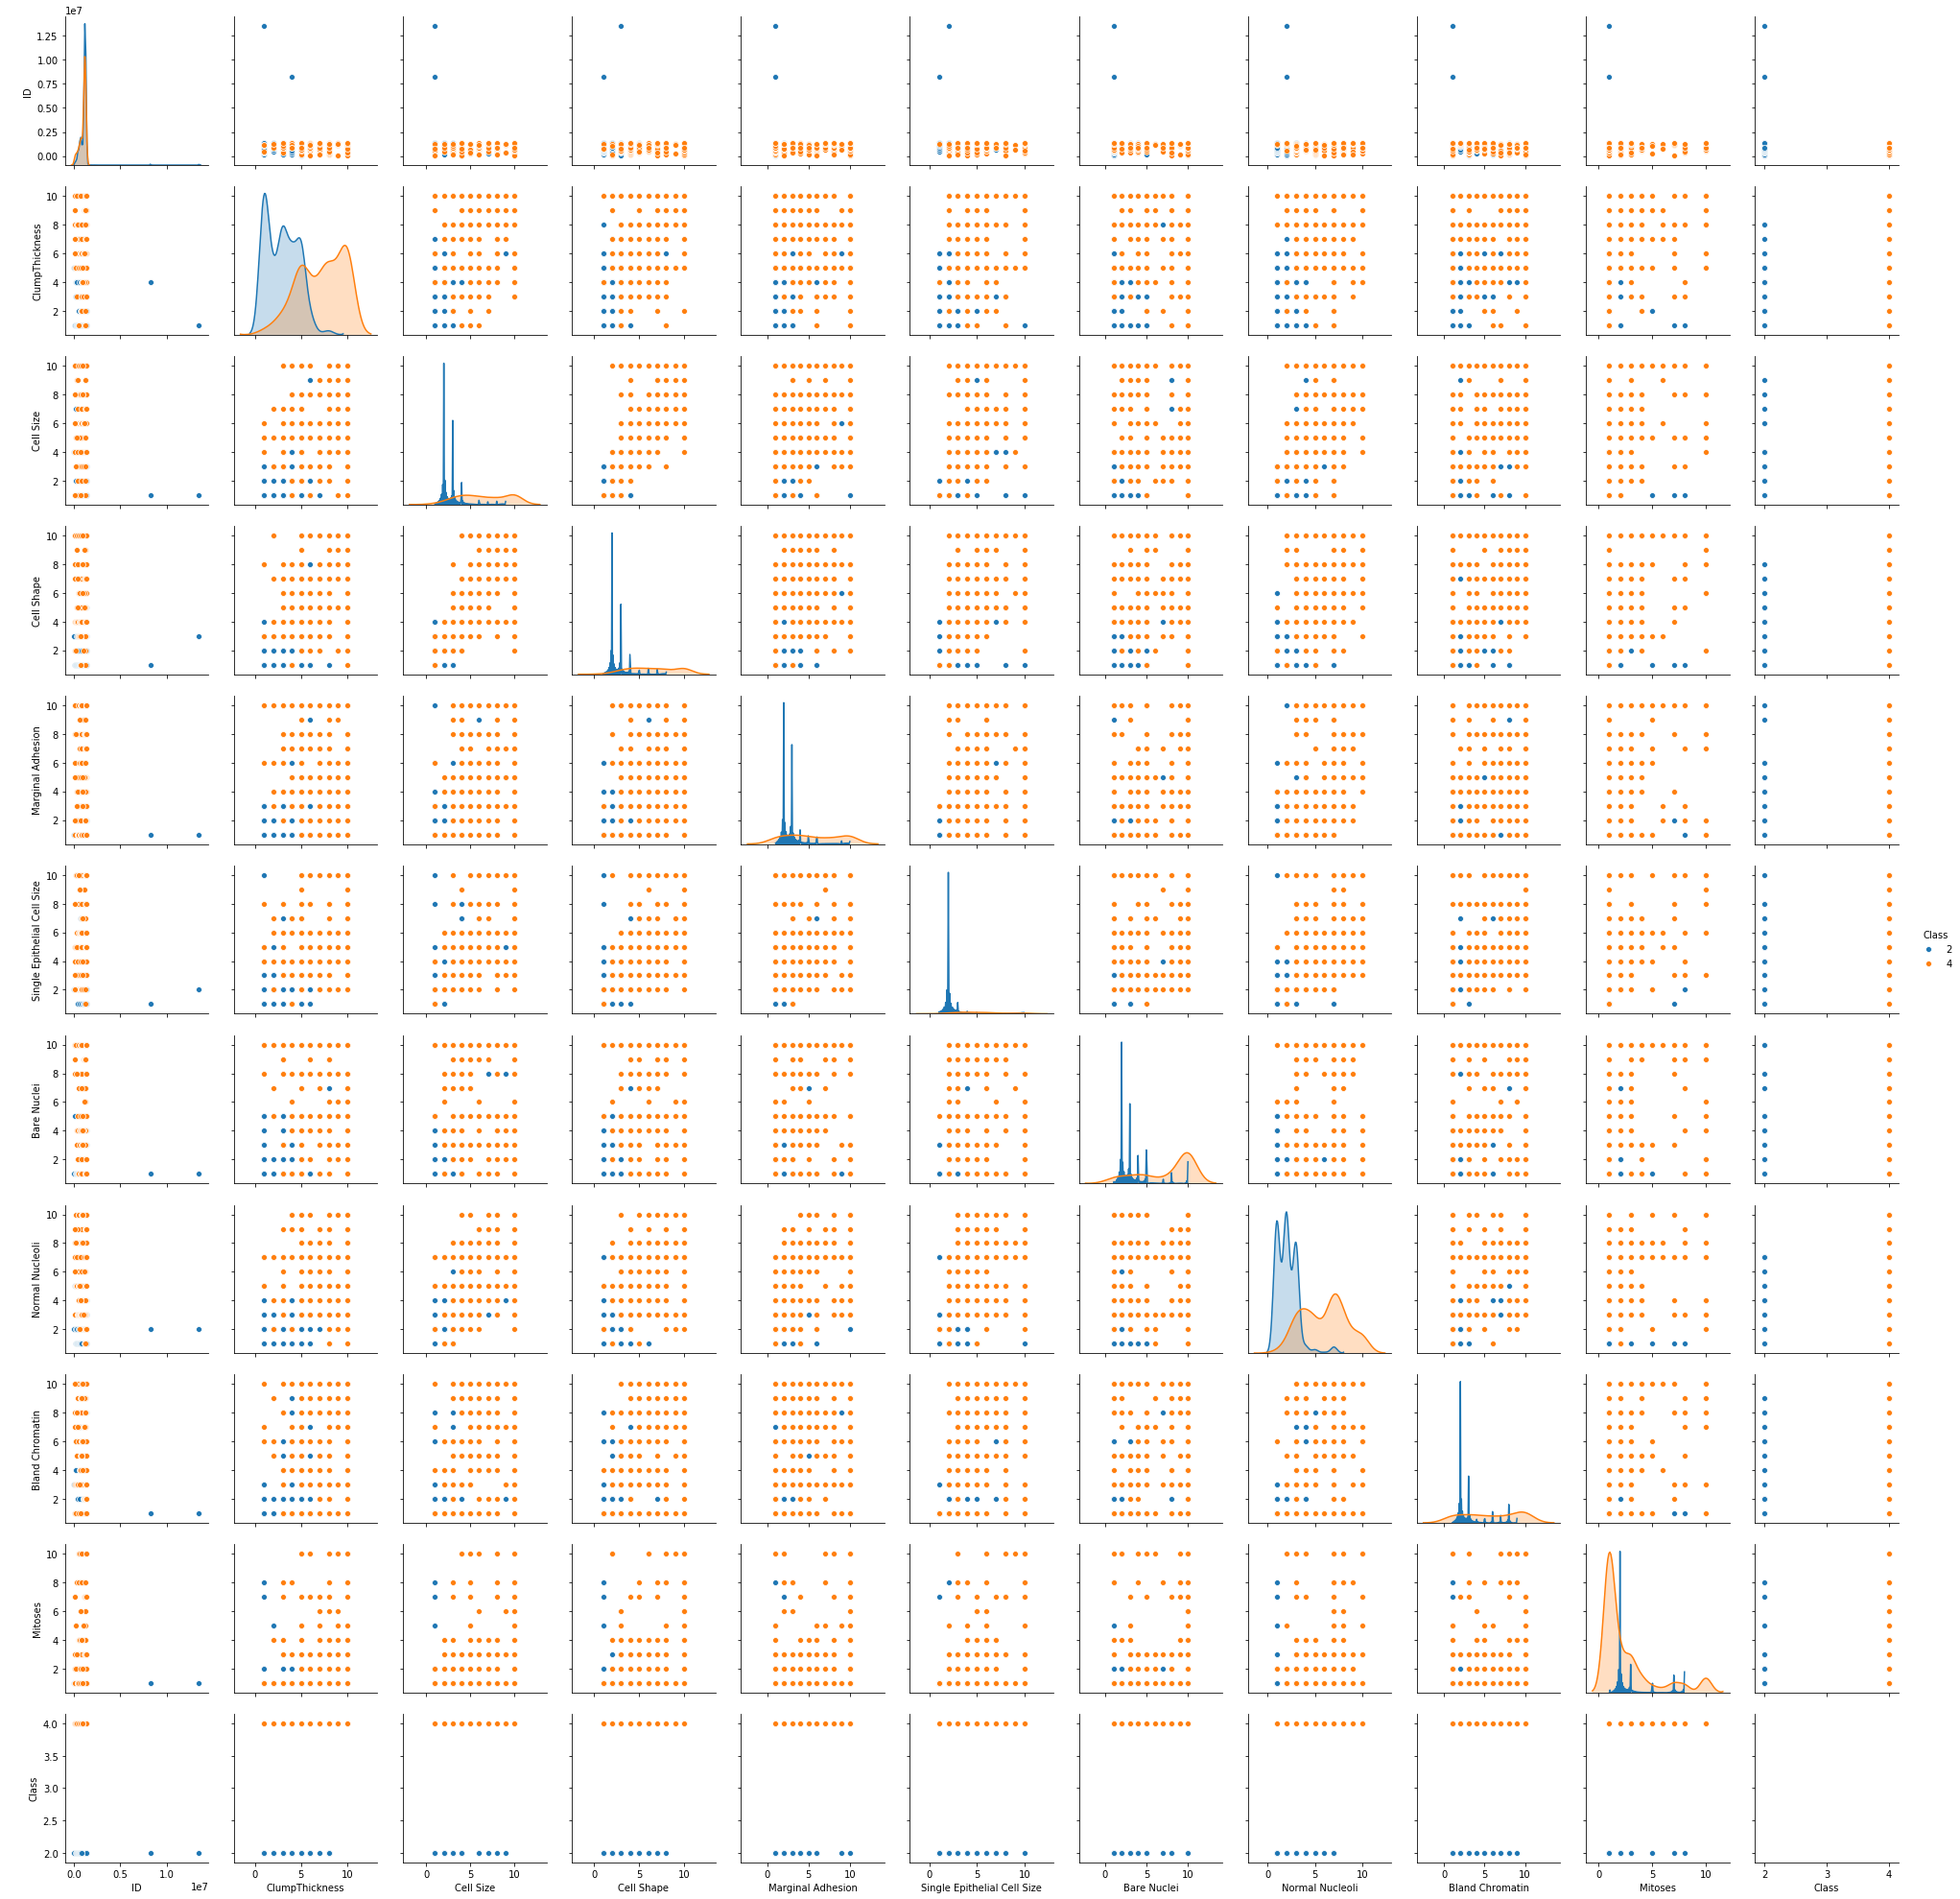

In [58]:
#Let us check for pair plots
sns.pairplot(cancer_data, hue = "Class")

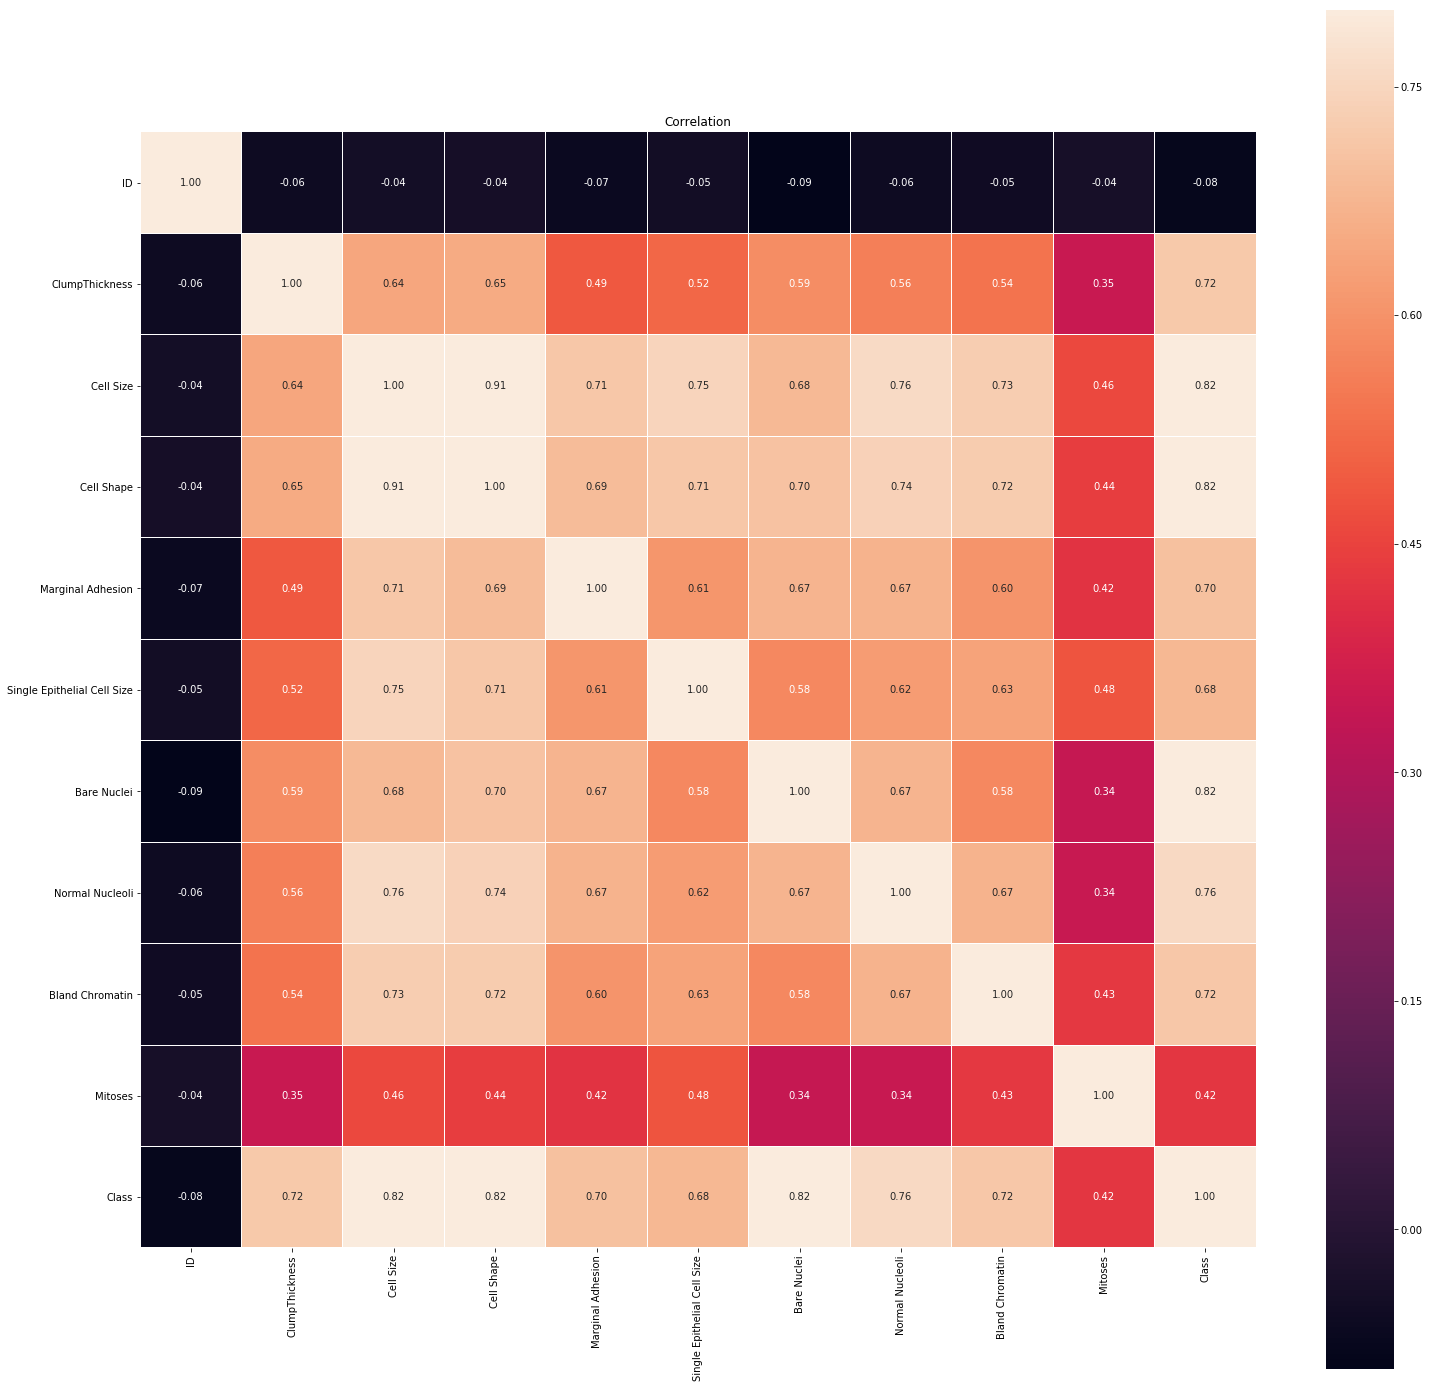

In [61]:
plt.figure(figsize=(25, 25))
ax = sns.heatmap(cancer_data.corr(), vmax=.8, square=True, fmt='.2f', annot=True, linecolor='white', linewidths=0.01)
plt.title('Correlation')
plt.show()

# Q5 Remove any unwanted columns or outliers, standardize variables in this pre-processing step

In [0]:
# We could see most of the outliers are now removed.

In [62]:
#Drop 'ID', 'Class' features
X = cancer_data.drop(["ID","Class"], axis=1)
# Get Target variable in y
y = cancer_data["Class"]

In [64]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


from sklearn.decomposition import PCA
from scipy.stats import zscore
sc = StandardScaler()
X_std =  sc.fit_transform(X)  
X_std

/anaconda3/lib/python3.7/site-packages/sklearn/preprocessing/data.py:625: DataConversionWarning: Data with input dtype int64 were all converted to float64 by StandardScaler.
  return self.partial_fit(X, y)
/anaconda3/lib/python3.7/site-packages/sklearn/base.py:462: DataConversionWarning: Data with input dtype int64 were all converted to float64 by StandardScaler.
  return self.fit(X, **fit_params).transform(X)


array([[ 0.20282286, -0.70169775, -0.74503981, ..., -0.17861602,
        -0.61508162, -0.34486918],
       [ 0.20282286,  0.28506471,  0.26891969, ..., -0.17861602,
        -0.28886616, -0.34486918],
       [-0.50757194, -0.70169775, -0.74503981, ..., -0.17861602,
        -0.61508162, -0.34486918],
       ...,
       [ 0.20282286,  2.25858965,  2.2968387 , ...,  1.86864398,
         2.32085757,  0.23552042],
       [-0.15237454,  1.600748  ,  0.9448927 , ...,  2.68754798,
         1.0159957 , -0.34486918],
       [-0.15237454,  1.600748  ,  1.6208657 , ...,  2.68754798,
         0.36356477, -0.34486918]])

# Q6 Create a covariance matrix for identifying Principal components

In [0]:
# PCA
# Step 1 - Create covariance matrix


In [65]:
# PCA
# Step 1 - Create covariance matrix
cov_matrix = np.cov(X_std.T)
print('Covariance Matrix \n%s', cov_matrix)

Covariance Matrix 
%s [[1.00145138 0.64410677 0.65453792 0.48842317 0.51800374 0.59150555
  0.56187702 0.53628373 0.35070402]
 [0.64410677 1.00145138 0.9066632  0.71396807 0.74806589 0.68556472
  0.76073447 0.7281282  0.46058509]
 [0.65453792 0.9066632  1.00145138 0.6917849  0.71527957 0.70518656
  0.73964761 0.72557104 0.44107467]
 [0.48842317 0.71396807 0.6917849  1.00145138 0.60916409 0.67348849
  0.67083263 0.60310209 0.41761286]
 [0.51800374 0.74806589 0.71527957 0.60916409 1.00145138 0.58132945
  0.62142658 0.63480034 0.48321685]
 [0.59150555 0.68556472 0.70518656 0.67348849 0.58132945 1.00145138
  0.67373075 0.57900023 0.34332099]
 [0.56187702 0.76073447 0.73964761 0.67083263 0.62142658 0.67373075
  1.00145138 0.67006996 0.34426827]
 [0.53628373 0.7281282  0.72557104 0.60310209 0.63480034 0.57900023
  0.67006996 1.00145138 0.42811085]
 [0.35070402 0.46058509 0.44107467 0.41761286 0.48321685 0.34332099
  0.34426827 0.42811085 1.00145138]]


# Q7 Identify eigen values and eigen vector

In [0]:
# Step 2- Get eigen values and eigen vector

In [66]:
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
print('Eigen Vectors \n%s', eigenvectors)
print('\n Eigen Values \n%s', eigenvalues)

Eigen Vectors 
%s [[-0.30202869  0.14902209 -0.86872874 -0.00254656 -0.02905197  0.26616691
  -0.19399832 -0.1501391  -0.00300703]
 [-0.38089144  0.04833557  0.03657788 -0.73669737  0.18962075 -0.43946502
  -0.23349186  0.09850317  0.12335951]
 [-0.37721125  0.08333455 -0.02039666  0.66430356  0.16770378 -0.58940349
  -0.15127833  0.06480163  0.08028927]
 [-0.33430954  0.05023423  0.39037637  0.04590901 -0.48684422  0.19404134
  -0.4924605  -0.46232255 -0.0168367 ]
 [-0.33589151 -0.17389022  0.15761632  0.06657451  0.32855055  0.38975065
   0.21090367 -0.06957883  0.72006348]
 [-0.33284901  0.24716817 -0.0294455  -0.07105867 -0.55680581 -0.15915546
   0.69544634  0.01237327  0.05514693]
 [-0.34648894  0.22989544  0.18320773  0.06252437  0.00966191  0.39882942
  -0.12659342  0.73810848 -0.26387659]
 [-0.3364694  -0.02071698  0.1357351  -0.02018486  0.47674458  0.1133626
   0.31256571 -0.41188028 -0.60004044]
 [-0.22972022 -0.90629849 -0.11603305  0.0080874  -0.22956737 -0.04272175
   0.

# Q8 Find variance and cumulative variance by each eigen vector

In [67]:
tot = sum(eigenvalues)
# an array of variance explained by each 
# eigen vector... there will be 9 entries as there are 9 eigen vectors)
var_explained = [(i / tot) for i in sorted(eigenvalues, reverse=True)] 

cum_var_exp = np.cumsum(var_explained)  # an array of cumulative variance. There will be 9 entries with 8 th entry 
# cumulative reaching almost 100%
print("Cumulative Variance: \n", cum_var_exp)

Cumulative Variance: 
 [0.65555407 0.7417686  0.80177479 0.85352247 0.89466669 0.9281611
 0.96072714 0.9899621  1.        ]


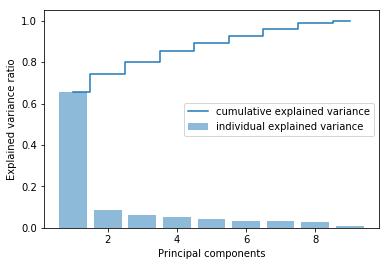

In [68]:
plt.bar(range(1,10), var_explained, alpha=0.5, align='center', label='individual explained variance')
plt.step(range(1,10),cum_var_exp, where= 'mid', label='cumulative explained variance')
plt.ylabel('Explained variance ratio')
plt.xlabel('Principal components')
plt.legend(loc = 'best')
plt.show()

# Q9 Use PCA command from sklearn and find Principal Components. Transform data to components formed

In [74]:
from sklearn.decomposition import PCA

In [75]:
PCA = PCA(n_components=5)
PCA.fit(X_std)

PCA(copy=True, iterated_power='auto', n_components=5, random_state=None,
  svd_solver='auto', tol=0.0, whiten=False)

In [80]:
X_PCA = PCA.transform(X_std)
X_PCA.shape

(690, 5)

In [88]:
PCA.components_
#Print_ PCA components 
PCA.components_.shape
PCA.explained_variance_

array([5.90854977, 0.77705689, 0.5408396 , 0.466405  , 0.37083545])

In [90]:
PCA.explained_variance_

array([5.90854977, 0.77705689, 0.5408396 , 0.466405  , 0.37083545])

In [89]:
PCA.explained_variance_ratio_

array([0.65555407, 0.08621452, 0.0600062 , 0.05174767, 0.04114422])

# Q10 Find correlation between components and features

In [92]:
df = pd.DataFrame(X_PCA)

/anaconda3/lib/python3.7/site-packages/scipy/stats/stats.py:1713: FutureWarning: Using a non-tuple sequence for multidimensional indexing is deprecated; use `arr[tuple(seq)]` instead of `arr[seq]`. In the future this will be interpreted as an array index, `arr[np.array(seq)]`, which will result either in an error or a different result.
  return np.add.reduce(sorted[indexer] * weights, axis=axis) / sumval
/anaconda3/lib/python3.7/site-packages/statsmodels/nonparametric/kde.py:488: RuntimeWarning: invalid value encountered in true_divide
  binned = fast_linbin(X, a, b, gridsize) / (delta * nobs)
/anaconda3/lib/python3.7/site-packages/statsmodels/nonparametric/kdetools.py:34: RuntimeWarning: invalid value encountered in double_scalars
  FAC1 = 2*(np.pi*bw/RANGE)**2
/anaconda3/lib/python3.7/site-packages/numpy/core/fromnumeric.py:83: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


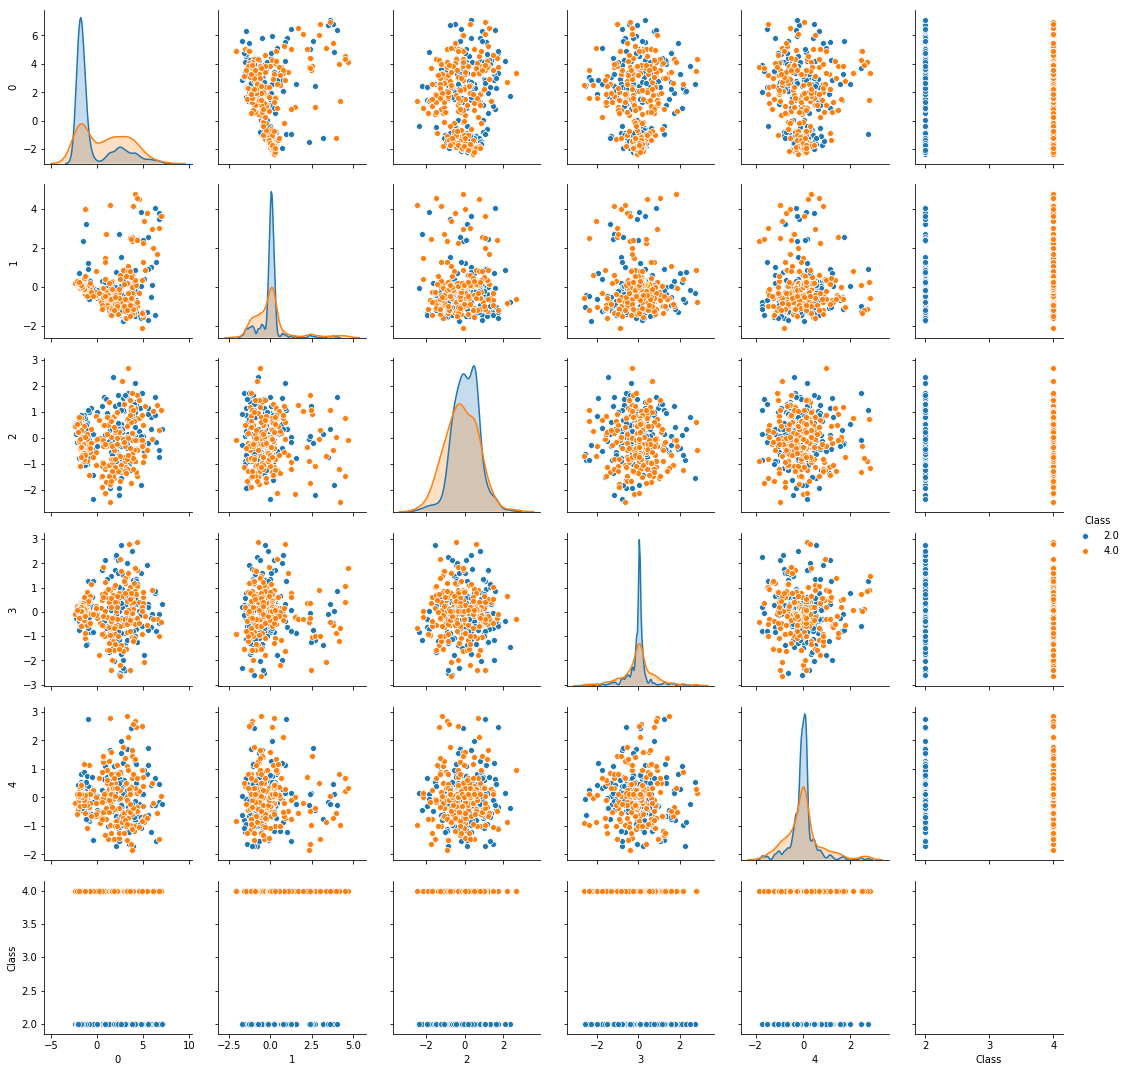

In [93]:
# Pairplot analysis 
df = df.join(y)
sns.pairplot(df, diag_kind='kde',hue="Class")

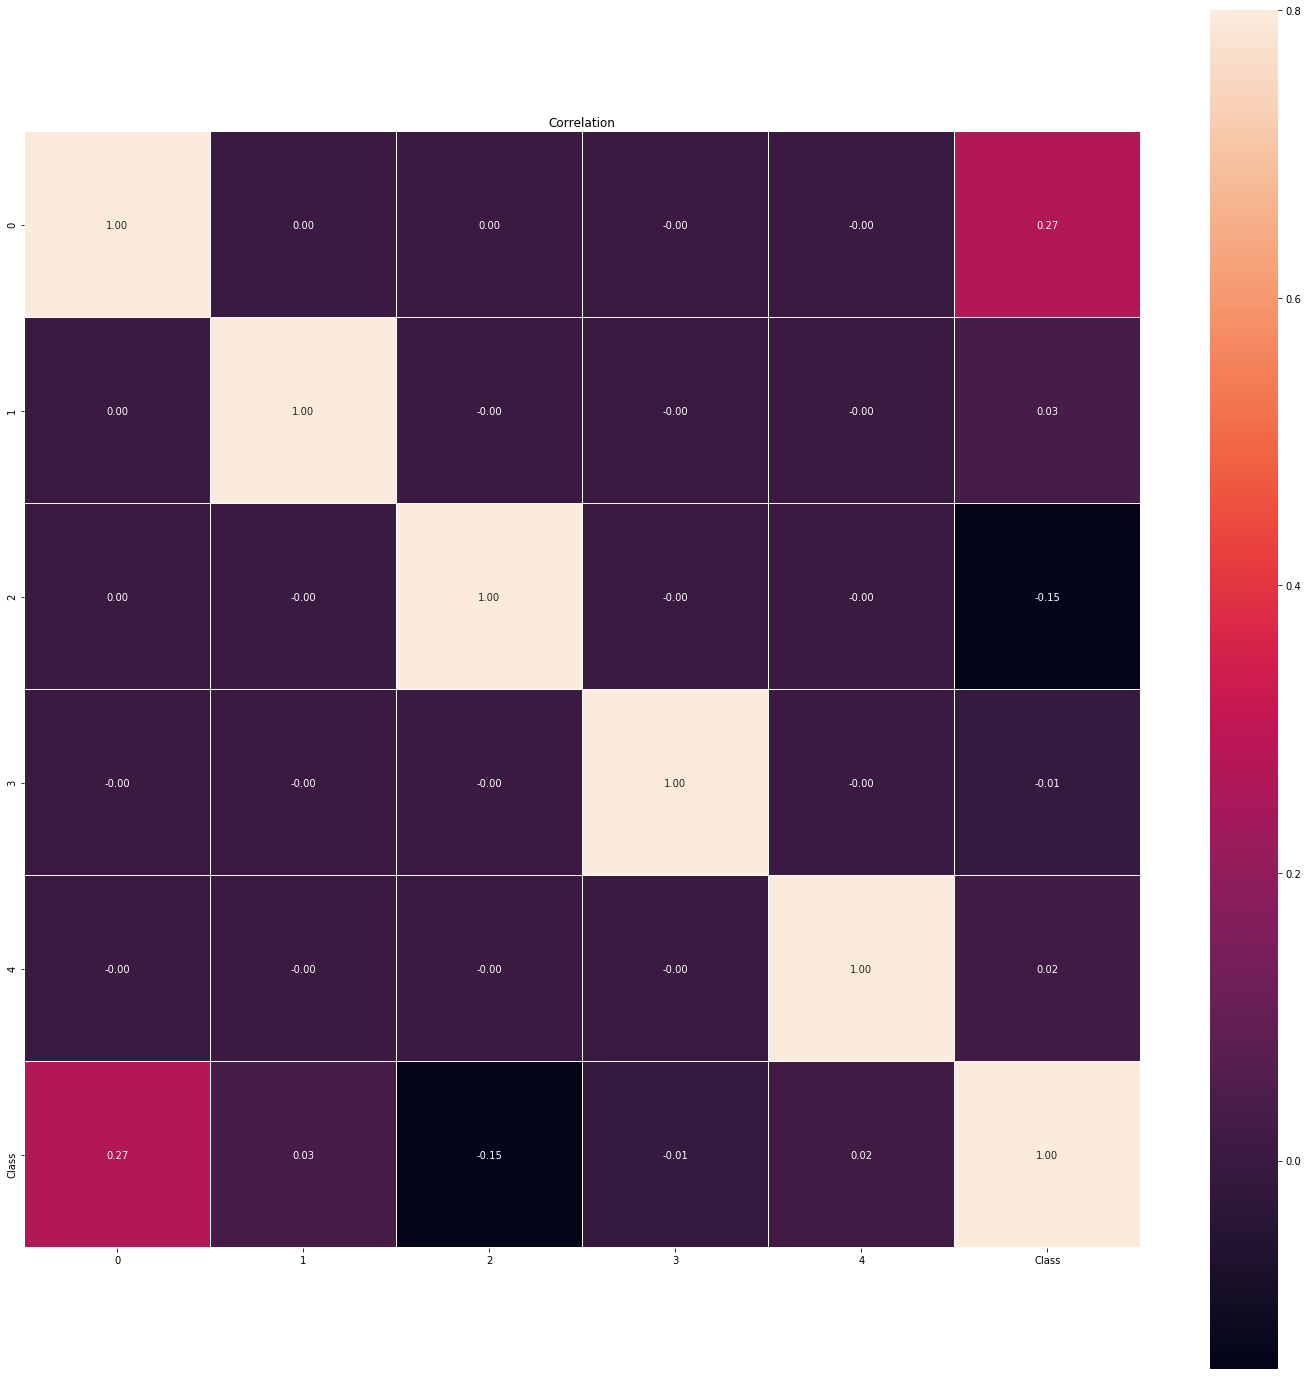

In [94]:
plt.figure(figsize=(25, 25))
ax = sns.heatmap(df.corr(), vmax=.8, square=True, fmt='.2f', annot=True, linecolor='white', linewidths=0.01)
plt.title('Correlation')
plt.show()

In [ ]:
# Correlataion after the PCA 